## Support Vector Machine

In [82]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [83]:
from sklearn.datasets import make_classification
X,y=make_classification(n_samples=1000,n_classes=2,n_features=2,n_redundant=0,n_clusters_per_class=1)

In [84]:
X=pd.DataFrame(X)
y=pd.Series(y)

<Axes: xlabel='0', ylabel='1'>

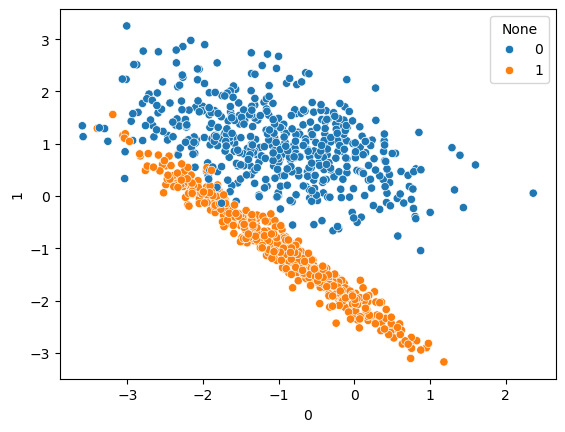

In [85]:
sns.scatterplot(x=X[0],y=X[1],hue=y)

## Support Vector Machine

In [86]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.30,random_state=42)

In [87]:
from sklearn.svm import SVC
svc=SVC(kernel='linear')

In [88]:
model=svc.fit(X_train,y_train)

In [89]:
y_pred=model.predict(X_test)

#### Performance Metrics

In [90]:
from sklearn.metrics import classification_report, confusion_matrix
cr=classification_report(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)

In [91]:
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       149
           1       0.95      0.98      0.96       151

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

[[141   8]
 [  3 148]]


#### Kernels

In [92]:
rbf=SVC(kernel='rbf')
model=svc.fit(X_train,y_train)
y_pred=model.predict(X_test)
cr=classification_report(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       149
           1       0.95      0.98      0.96       151

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

[[141   8]
 [  3 148]]


In [93]:
poly=SVC(kernel='poly')
model=poly.fit(X_train,y_train)
y_pred1=model.predict(X_test)
cr=classification_report(y_test,y_pred1)
cm=confusion_matrix(y_test,y_pred1)
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       149
           1       0.95      0.97      0.96       151

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

[[141   8]
 [  5 146]]


In [94]:
sigmoid=SVC(kernel='sigmoid')
model=svc.fit(X_train,y_train)
y_pred=model.predict(X_test)
cr=classification_report(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.98      0.95      0.96       149
           1       0.95      0.98      0.96       151

    accuracy                           0.96       300
   macro avg       0.96      0.96      0.96       300
weighted avg       0.96      0.96      0.96       300

[[141   8]
 [  3 148]]


## Grid Search CV

In [101]:
from sklearn.model_selection import GridSearchCV
params_grid={'C':[0.1,1,10,100,1000],
             'gamma':[1,0.1,0.01,0.001,0.0001],
             'kernel':['rbf']}

In [102]:
grid=GridSearchCV(SVC(),param_grid=params_grid,cv=5,verbose=3,refit=True)

In [103]:
grid.fit(X_train,y_train)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV 1/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.971 total time=   0.0s
[CV 2/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.979 total time=   0.0s
[CV 3/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.971 total time=   0.0s
[CV 4/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.979 total time=   0.0s
[CV 5/5] END ........C=0.1, gamma=1, kernel=rbf;, score=0.986 total time=   0.0s
[CV 1/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.957 total time=   0.0s
[CV 2/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.964 total time=   0.0s
[CV 3/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.971 total time=   0.0s
[CV 4/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.964 total time=   0.0s
[CV 5/5] END ......C=0.1, gamma=0.1, kernel=rbf;, score=0.986 total time=   0.0s
[CV 1/5] END .....C=0.1, gamma=0.01, kernel=rbf;, score=0.950 total time=   0.0s
[CV 2/5] END .....C=0.1, gamma=0.01, kernel=rbf

,estimator,SVC()
,param_grid,"{'C': [0.1, 1, ...], 'gamma': [1, 0.1, ...], 'kernel': ['rbf']}"
,scoring,None
,n_jobs,None
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,1


In [104]:
grid.best_score_,grid.best_params_

(np.float64(0.9871428571428572), {'C': 1, 'gamma': 1, 'kernel': 'rbf'})

In [106]:
g_pred=grid.predict(X_test) 
cr=classification_report(y_test,g_pred)
cm=confusion_matrix(y_test,g_pred)
print(cr)
print(cm)

              precision    recall  f1-score   support

           0       0.97      0.94      0.95       149
           1       0.94      0.97      0.95       151

    accuracy                           0.95       300
   macro avg       0.95      0.95      0.95       300
weighted avg       0.95      0.95      0.95       300

[[140   9]
 [  5 146]]
